In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from PIL import Image


# increase font size
plt.rcParams.update({'font.size': 14})

# define a colormap which is the composition of two colormaps:
#- red to black from 0 to 0.5, and black to white from 0.5 to 1

from matplotlib.colors import LinearSegmentedColormap

colors = [(1, 0, 0), (0, 0, 0), (1, 1, 1)]  # Red to black to white
n_bins = 100  # Number of bins
cmap_name = 'red_black_white'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)


## An image is an approximation to a function

Just as in the lectures, the image is a **rasterization** of an - in principle - infinitely high resolution analog photograph.

(1285, 1920)


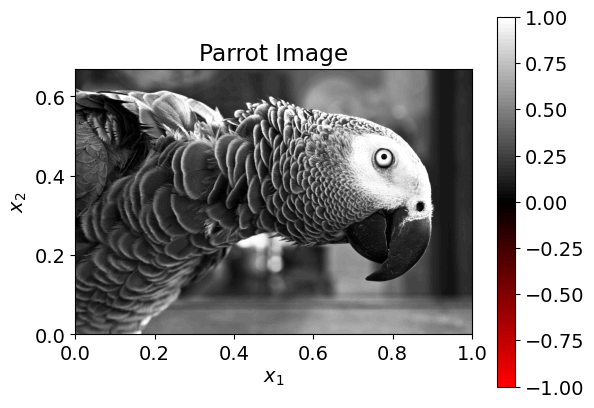

In [2]:
def load_bird(fname):
    # read parrot.png
    parrot = Image.open(fname).convert('L')
    # normalize values to [0.0 ... 1.0]
    P = np.array(parrot, dtype=float) / 255.0
    print(P.shape)
    return P

def show_function(P, title=None, vmax=1):
    plt.imshow(P, extent=(0,1,0,1*P.shape[0]/P.shape[1]), vmin=-vmax, vmax=vmax, cmap=cm)
    plt.colorbar()
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    if title is not None:
        plt.title(title)
    plt.show()
    

P = load_bird('parrot.png')

# make coordinate grids for the image
x1 = np.linspace(0,1, P.shape[1])
x2 = np.linspace(0,1*P.shape[0]/P.shape[1], P.shape[0])
X1, X2 = np.meshgrid(x1, x2)

show_function(P, title='Parrot Image')


(1285, 1920)


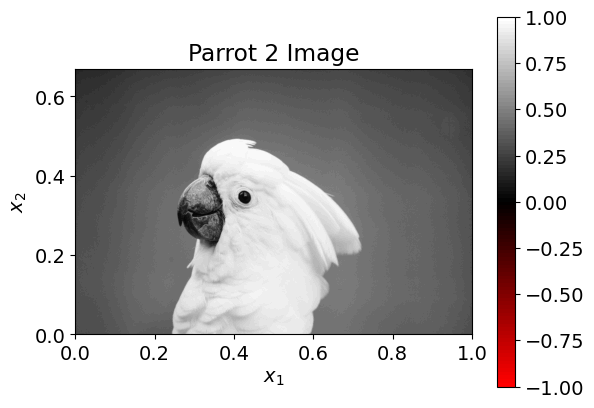

In [3]:
Q = load_bird('parrot2.png')
show_function(Q, title='Parrot 2 Image')

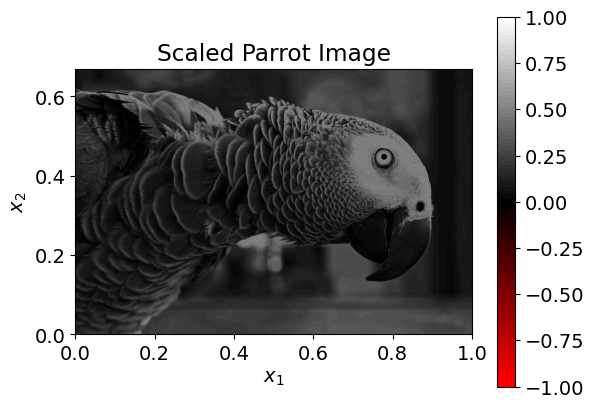

In [4]:
# let us scale
scale_factor = 0.5
P_scaled = scale_factor * P
show_function(P_scaled, title='Scaled Parrot Image')

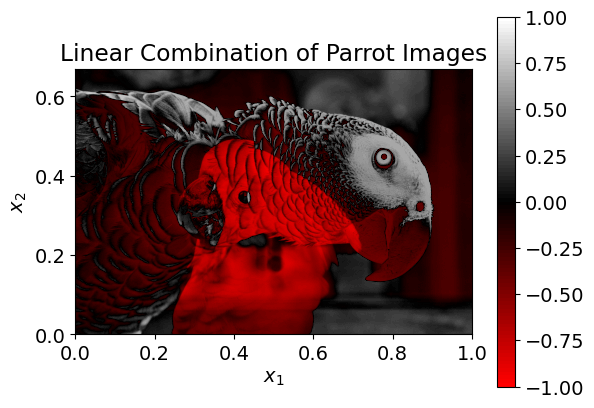

In [6]:
# Let us make a linear combination of the two images
linear_combination = (P -  Q)
show_function(linear_combination, title='Linear Combination of Parrot Images')


In [7]:
# Let us compute the norm and inner inner product!

def inner_product(P, Q):
    dx1 = x1[1] - x1[0]
    dx2 = x2[1] - x2[0]
    dtau = dx1 * dx2
    return np.sum(P * Q) * dtau

def norm(P):
    return np.sqrt(inner_product(P, P))
# compute the norm of the two parrot images
norm_P = norm(P)
norm_Q = norm(Q)
print(f"Norm of P: {norm_P}")
print(f"Norm of Q: {norm_Q}")

# compute the inner product of the two parrot images
inner_product_value = inner_product(P, Q)
print(f"Inner product of P and Q: {inner_product_value}")


Norm of P: 0.34790858480003656
Norm of Q: 0.42570572347856217
Inner product of P and Q: 0.10652909837485602


In [8]:
# Let us compute the angle between the two images

cos_theta = inner_product(P, Q) / (np.sqrt(inner_product(P, P)) * np.sqrt(inner_product(Q, Q)))
theta = np.arccos(cos_theta) * 180 / np.pi
print(f"Angle between P and Q: {theta} degrees")

Angle between P and Q: 44.00552874409464 degrees


In [9]:
# Let us compute the distance between the two images

distance = norm(P - Q)
print(f"Distance between P and Q: {distance}")

Distance between P and Q: 0.29867632920982917


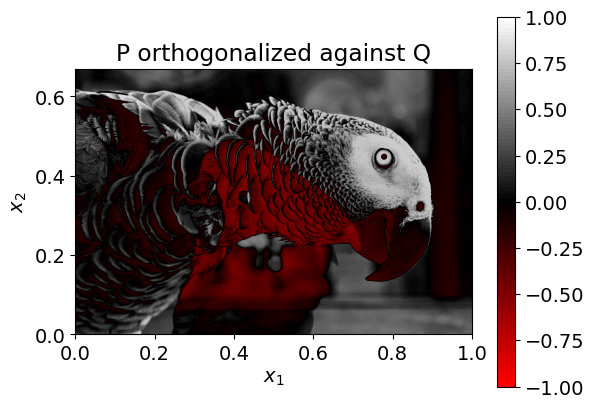

Inner product of P projected out along Q with Q: -6.544165572225212e-17


In [10]:
# Let us compute a new image that projects out the component of P along Q
projection_coefficient = inner_product(P, Q) / inner_product(Q, Q)
P_projected = P - projection_coefficient * Q
show_function(P_projected, title='P orthogonalized against Q')

# Compute the inner product of the projected image with Q
inner_product_projected_Q = inner_product(P_projected, Q)
print(f"Inner product of P projected out along Q with Q: {inner_product_projected_Q}")



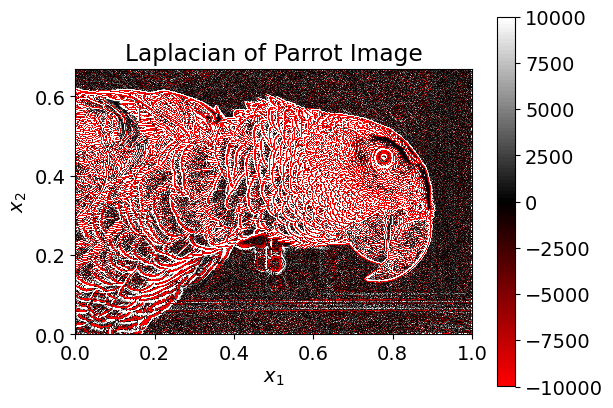

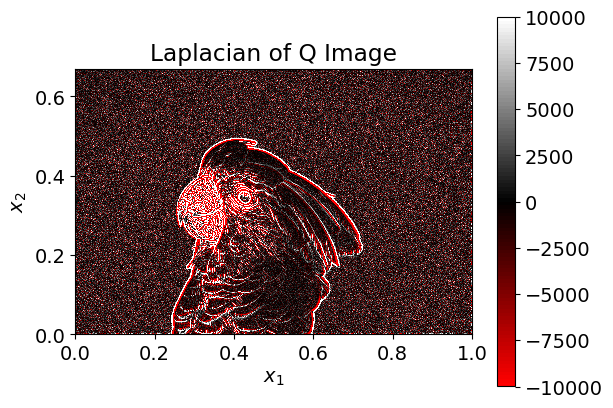

In [11]:
# Define a linear operator: The Laplacian
def laplacian(P):
    # Compute the Laplacian using finite differences
    P_xx = np.zeros_like(P)
    P_yy = np.zeros_like(P)
    dx = x1[1] - x1[0]
    dy = x2[1] - x2[0]
    
    P_xx[:, 1:-1] = (P[:, 2:] - 2 * P[:, 1:-1] + P[:, :-2])/dx**2
    P_yy[1:-1, :] = (P[2:, :] - 2 * P[1:-1, :] + P[:-2, :])/dy**2
    return P_xx + P_yy

LP = laplacian(P)
show_function(LP, title='Laplacian of Parrot Image', vmax=10000)

LQ = laplacian(Q)
LQ = laplacian(Q)
show_function(LQ, title='Laplacian of Q Image', vmax=10000)